In [1]:
!pip install pyotp mplfinance pandas_ta fyers_apiv3 pygame stable-baselines3 gymnasium

In [2]:
import requests
import base64
from datetime import datetime, timedelta, date
from datetime import time as dt_time
import time
import threading
import pyotp
from pytz import timezone
import pandas as pd
import numpy as np
from urllib.parse import urlparse, parse_qs
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import mplfinance as mpf
import pandas_ta as ta
import pygame
import os
import pytz
import json
import re
import random
import pickle

import gymnasium as gym
from gymnasium import spaces
from IPython.display import display, clear_output

from fyers_apiv3 import fyersModel
from fyers_apiv3.FyersWebsocket import data_ws

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense, LSTM, GRU, Dropout, Attention, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.callbacks import Callback, ModelCheckpoint
from scipy.signal import argrelextrema
import tensorflow as tf
from tensorflow.keras import layers
from scipy.signal import find_peaks

pygame 2.6.1 (SDL 2.28.4, Python 3.10.12)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [3]:
def get_index_symbol_and_quantity(index):

    # Dictionary mapping index name to index symbols
    index_symbols = {
        'Bankex': 'BSE:BANKEX-INDEX',
        'Finnifty': 'NSE:FINNIFTY-INDEX',
        'Bank Nifty': 'NSE:NIFTYBANK-INDEX',
        'Nifty': 'NSE:NIFTY50-INDEX',
        'Sensex': 'BSE:SENSEX-INDEX'
    }

    # Determine the index symbol for the given index
    index_symbol = index_symbols.get(index, 'Invalid Index')

    # Determine the quantity based on the index symbol
    if index_symbol == "NSE:NIFTY50-INDEX":
        quantity = 25  # 25 is one lot for Nifty
    elif index_symbol == "NSE:NIFTYBANK-INDEX":
        quantity = 15  # 15 is one lot for Bank Nifty
    elif index_symbol == "NSE:FINNIFTY-INDEX":
        quantity = 40  # 40 is one lot for Finnifty
    elif index_symbol == "BSE:SENSEX-INDEX":
        quantity = 20  # 20 is two lot for Sensex
    elif index_symbol == "BSE:BANKEX-INDEX":
        quantity = 15  # 15 is one lot for Bankex
    else:
        quantity = 0  # Default value if none of the conditions match

    return index_symbol, quantity

In [4]:
app_id = "TS79V3NXK1-100"
secret_key = "KQCPB0FJ74"
redirect_uri = "https://google.com"
fyers_user = "XM22383"
fyers_pin = "4628"
fyers_totp = "EAQD6K4IUYOEGPJNVE6BMPTUSDCWIOHW"
response_type = "code"
state = "sample_state"
grant_type = "authorization_code"

fyers = None
fyers_socket = None

index_symbol, quantity = get_index_symbol_and_quantity("Bank Nifty")

interval_minutes = 2 # Set the interval to 1, 5, or 15 minutes

ist_timezone = pytz.timezone("Asia/Kolkata")

#Variables
ce_ltp = 0
pe_ltp = 0
index_ltp = 0
buy_sell_checked = False
ce_strike = None
pe_strike = None
ce_symbol = None
pe_symbol = None

target = 80
trailing_sl = 40

brokerage = 100

fixed_ltp = 0
fixed_index_ltp = 0
prev_ltp = 0
target_inside = 0
target_index_inside = 0
trailing_sl_inside = 0
trailing_index_inside = 0

active_order = False

sl_hit_condition = False
total_loss = 0
total_profit = 0
overall_win = 0
overall_loss = 0
total_points = 0

unsubscribe_done = False

active_order_sleep = 1

In [5]:
session = fyersModel.SessionModel(
    client_id=app_id,
    secret_key=secret_key,
    redirect_uri=redirect_uri,
    response_type=response_type,
    grant_type=grant_type
)

def getEncodedString(string):
    string = str(string)
    base64_bytes = base64.b64encode(string.encode("ascii"))
    return base64_bytes.decode("ascii")

if session is not None:
    session.generate_authcode()

    url_send_login_otp = "https://api-t2.fyers.in/vagator/v2/send_login_otp_v2"
    res = requests.post(url=url_send_login_otp, json={"fy_id": getEncodedString(fyers_user), "app_id": "2"}).json()

    if datetime.now().second % 30 > 27:
        time.sleep(5)

    url_verify_otp = "https://api-t2.fyers.in/vagator/v2/verify_otp"
    res2 = requests.post(url=url_verify_otp, json={"request_key": res["request_key"], "otp": pyotp.TOTP(fyers_totp).now()}).json()

    ses = requests.Session()
    url_verify_otp2 = "https://api-t2.fyers.in/vagator/v2/verify_pin_v2"
    payload2 = {"request_key": res2["request_key"], "identity_type": "pin", "identifier": getEncodedString(fyers_pin)}
    res3 = ses.post(url=url_verify_otp2, json=payload2).json()

    ses.headers.update({'authorization': f"Bearer {res3['data']['access_token']}"})

    tokenurl = "https://api-t1.fyers.in/api/v3/token"
    payload3 = {
        "fyers_id": fyers_user,
        "app_id": app_id[:-4],
        "redirect_uri": redirect_uri,
        "appType": "100",
        "code_challenge": "",
        "state": "None",
        "scope": "",
        "nonce": "",
        "response_type": "code",
        "create_cookie": True
    }

    res3 = ses.post(url=tokenurl, json=payload3).json()

    url = res3['Url']
    parsed = urlparse(url)
    auth_code = parse_qs(parsed.query)['auth_code'][0]

    session.set_token(auth_code)

    auth_response = session.generate_token()
    access_token = auth_response["access_token"]

    fyers = fyersModel.FyersModel(client_id=app_id, token=access_token)

    ws_token = app_id + ":" + access_token
    fyers_socket = data_ws.FyersDataSocket(access_token=ws_token, log_path="")

pd.DataFrame(fyers.get_profile())

,s,code,message,data
fy_id,ok,200,,XM22383
name,ok,200,,MARSHAL TUDU
image,ok,200,,https://myaccount-docs-prod.fyers.in/Profile_P...
display_name,ok,200,,None
pin_change_date,ok,200,,25-09-2023 17:16:16
email_id,ok,200,,iammarshal22@gmail.com
pwd_change_date,ok,200,,01-06-2022 20:36:31
PAN,ok,200,,---------
mobile_number,ok,200,,8458060663
totp,ok,200,,True


In [6]:
def fetch_candle_data(number):
    while True:
        try:
            today = date.today()
            yesterday = today - timedelta(number)

            data = {
                "symbol": index_symbol,
                "resolution": interval_minutes,
                "date_format": "1",
                "range_from": yesterday,
                "range_to": today,
                "cont_flag": "1"
            }

            result = fyers.history(data=data)

            if result is not None:
                train_df = pd.DataFrame(result['candles'], columns=['datetime', 'open', 'high', 'low', 'close', 'volume'])
                return train_df
        except Exception as e:
            print(f"Error fetching Candle Data: {e}")
            time.sleep(active_order_sleep)

In [7]:
def fetch_train_candle_data(days_count):
    train_df = pd.DataFrame()

    while True:
        try:
            date_increment = 100
            for i in range(days_count):
                today = date.today() - timedelta(date_increment)
                yesterday = today - timedelta(100)

                data = {
                    "symbol": index_symbol,
                    "resolution": interval_minutes,
                    "date_format": "1",
                    "range_from": yesterday,
                    "range_to": today,
                    "cont_flag": "1"
                }

                result = fyers.history(data=data)

                if result is not None:
                    temp_df = pd.DataFrame(result['candles'], columns=['datetime', 'open', 'high', 'low', 'close', 'volume'])
                    train_df = pd.concat([temp_df, train_df], ignore_index=True)

                date_increment += 100

            if train_df is not None:
                return train_df

        except Exception as e:
            print(f"Error fetching Candle Data: {e}")
            time.sleep(active_order_sleep)

In [8]:
train_df = fetch_candle_data(100)

#train_df = fetch_train_candle_data(25)

print(len(train_df))

train_df = train_df.drop_duplicates(subset='datetime', keep='first')

print(len(train_df))

12470
12470


In [9]:
class DataProcessor:
    def __init__(self, train_df, peak_length=14, indicator_length=14):
        """
        Initialize the DataProcessor with separate lengths for peak detection and indicators.
        :param train_df: Input DataFrame with OHLC data.
        :param peak_length: Length used for peak detection (support/resistance).
        :param indicator_length: Length used for technical indicators.
        """
        self.train_df = train_df.copy()
        self.peak_length = peak_length  # Length for support and resistance peaks
        self.indicator_length = indicator_length  # Length for indicators like RSI, EMA, ATR

    def preprocess_datetime(self):
        """
        Preprocess the datetime column: convert to IST and handle duplicates or missing values.
        """
        ist = timezone('Asia/Kolkata')
        self.train_df['datetime'] = pd.to_datetime(self.train_df['datetime'], unit='s')
        self.train_df['datetime'] = (
            self.train_df['datetime']
            .dt.tz_localize('UTC')
            .dt.tz_convert(ist)
            .dt.tz_localize(None)
        )

        if self.train_df['datetime'].duplicated().any() or self.train_df['datetime'].isnull().any():
            raise ValueError("The 'datetime' column contains duplicates or missing values.")

        self.train_df.set_index(self.train_df['datetime'], inplace=True)
        self.train_df.drop(['datetime'], axis=1, inplace=True, errors='ignore')
        return self

    def clean_data(self):
        """
        Handle volume column and remove rows with missing or zero values.
        """
        if 'volume' in self.train_df.columns:
            self.train_df['volume'] = self.train_df['volume'].fillna(0)
            if (self.train_df['volume'] == 0).all() or self.train_df['volume'].isnull().all():
                self.train_df.drop(['volume'], axis=1, inplace=True, errors='ignore')
        return self

    def add_indicators(self):
        """
        Add technical indicators dynamically based on the provided indicator length.
        """
        # Relative Strength Index (RSI): Measures momentum and identifies overbought/oversold conditions.
        self.train_df['rsi'] = ta.rsi(self.train_df['close'], length=self.indicator_length)

        # Exponential Moving Average (EMA): Highlights price trends by smoothing data.
        self.train_df['ema'] = ta.ema(self.train_df['close'], length=self.indicator_length)

        # Average True Range (ATR): Indicates market volatility.
        self.train_df['atr'] = ta.atr(self.train_df['high'], self.train_df['low'], self.train_df['close'], length=self.indicator_length)

        # Bollinger Bands (BB): Identify price volatility and potential breakout zones.
        bbands = ta.bbands(self.train_df['close'], length=self.indicator_length)
        self.train_df['bb_upper'] = bbands['BBU_' + str(self.indicator_length) + '_2.0']
        self.train_df['bb_middle'] = bbands['BBM_' + str(self.indicator_length) + '_2.0']
        self.train_df['bb_lower'] = bbands['BBL_' + str(self.indicator_length) + '_2.0']

        # Historical Volatility (HV): Measures standard deviation of returns to capture market risk.
        self.train_df['hv'] = self.train_df['close'].pct_change().rolling(self.indicator_length).std() * (252 ** 0.5)

        # Price Spread Dynamics: Represents the difference between open and close relative to range.
        self.train_df['price_spread'] = (self.train_df['close'] - self.train_df['open']) / (
                self.train_df['high'] - self.train_df['low'])

        # Candle Length-to-ATR Ratio: Normalizes candle size by ATR to detect extremes.
        self.train_df['candle_to_atr'] = (self.train_df['high'] - self.train_df['low']) / self.train_df['atr']

        # Time-of-Day and Day-of-Week Features
        self.train_df['hour'] = self.train_df.index.hour
        self.train_df['day_of_week'] = self.train_df.index.dayofweek

        # Rate of Change (ROC)
        self.train_df['roc'] = ta.roc(self.train_df['close'], length=self.indicator_length)

        # Price Change
        self.train_df['price_change'] = self.train_df['close'].diff()

        # Target and Stop Loss based on ATR
        self.train_df['Target'] = self.train_df['atr'] * 2
        self.train_df['Stop Loss'] = self.train_df['atr']

        return self

    def calculate_support_resistance(self):
        """
        Calculate support and resistance levels using peaks detection with separate peak_length.
        """
        # Resistance (local maxima): Identifies potential sell zones.
        resistance_peaks, _ = find_peaks(self.train_df['high'], distance=self.peak_length)
        self.train_df['resistance'] = 0.0
        self.train_df.loc[self.train_df.index[resistance_peaks], 'resistance'] = self.train_df['high'].iloc[resistance_peaks]

        # Support (local minima): Identifies potential buy zones.
        support_peaks, _ = find_peaks(-self.train_df['low'], distance=self.peak_length)
        self.train_df['support'] = 0.0
        self.train_df.loc[self.train_df.index[support_peaks], 'support'] = self.train_df['low'].iloc[support_peaks]

        return self

    def detect_market_conditions(self):
        """
        Add features to detect market conditions (trending, range-bound, or volatile).
        """
        # Average Directional Index (ADX): Measures trend strength.
        adx = ta.adx(self.train_df['high'], self.train_df['low'], self.train_df['close'], length=self.indicator_length)
        self.train_df['adx'] = adx['ADX_' + str(self.indicator_length)]

        # RSI Oscillation Detection: Captures range-bound markets with RSI in the mid-zone.
        self.train_df['rsi_oscillation'] = ((self.train_df['rsi'] > 40) & (self.train_df['rsi'] < 60)).astype(int)

        # Price Compression Ratio: Identifies potential breakouts by comparing ATR to historical range.
        self.train_df['compression_ratio'] = self.train_df['atr'] / (
                self.train_df['high'].rolling(self.indicator_length).max()
                - self.train_df['low'].rolling(self.indicator_length).min()
        )
        return self

    def detect_market_regime(self):
        """
        Efficiently detect market regimes and assign integer labels:
        0 - Sideways, 1 - Trending, 2 - Volatile
        """
        self.train_df['market_regime'] = 0  # Default regime

        # Trending markets: Strong ADX
        trending_threshold = 25
        self.train_df.loc[self.train_df['adx'] > trending_threshold, 'market_regime'] = 1

        # Volatile markets: High Bollinger Band width
        self.train_df.loc[
            (self.train_df['bb_upper'] - self.train_df['bb_lower']) / self.train_df['bb_middle'] > 0.05,
            'market_regime'
        ] = 2

        return self

    def process(self):
        """
        Chain all preprocessing steps together.
        """
        return (
            self.preprocess_datetime()
            .clean_data()
            .add_indicators()
            .calculate_support_resistance()
            .detect_market_conditions()
            .detect_market_regime()
            .finalize()
        )

    def finalize(self):
        """
        Finalize the dataset by dropping rows with NaN values in any column.
        """
        self.train_df.dropna(inplace=True)
        return self



# 1. Data Preprocessing
data_processor = DataProcessor(train_df, peak_length=14, indicator_length=14)
processed_df = data_processor.process().train_df

processed_df

,open,high,low,close,rsi,ema,atr,bb_upper,bb_middle,bb_lower,...,roc,price_change,Target,Stop Loss,resistance,support,adx,rsi_oscillation,compression_ratio,market_regime
datetime,,,,,,,,,,,,,,,,,,,,,
2024-09-23 10:09:00,53906.25,53943.20,53901.05,53913.30,58.964713,53886.792929,44.956441,53915.847441,53882.700000,53849.552559,...,0.109927,5.90,89.912883,44.956441,0.00,0.00,7.590357,1,0.407030,0
2024-09-23 10:11:00,53917.45,53986.15,53909.20,53971.85,68.439415,53898.133872,47.569814,53944.993280,53890.814286,53836.635291,...,0.210924,58.55,95.139627,47.569814,53986.15,0.00,10.060816,0,0.310103,0
2024-09-23 10:13:00,53979.25,53981.80,53915.80,53934.35,59.037336,53902.962689,49.059988,53952.606858,53895.378571,53838.150285,...,0.118618,-37.50,98.119976,49.059988,0.00,0.00,12.193580,1,0.319817,0
2024-09-23 10:15:00,53935.50,53955.60,53912.30,53913.00,54.450914,53904.300997,48.598613,53954.518503,53898.435714,53842.352926,...,0.079450,-21.35,97.197226,48.598613,0.00,0.00,13.822339,1,0.316810,0
2024-09-23 10:17:00,53919.75,53929.80,53909.45,53919.60,55.599248,53906.340864,46.355351,53954.309746,53903.125000,53851.940254,...,0.121904,6.60,92.710701,46.355351,0.00,0.00,15.061501,1,0.326676,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 10:07:00,50683.95,50711.20,50679.75,50699.40,38.361002,50754.038947,57.819704,50812.888648,50751.882143,50690.875637,...,-0.334581,13.90,115.639408,57.819704,0.00,0.00,16.093323,0,0.288090,0
2024-12-31 10:09:00,50700.65,50708.45,50654.65,50679.85,36.442650,50744.147088,57.532582,50811.271192,50743.978571,50676.685951,...,-0.217856,-19.55,115.065165,57.532582,0.00,50654.65,16.969873,0,0.361726,0
2024-12-31 10:11:00,50679.15,50703.20,50674.85,50687.10,37.687142,50736.540809,55.448112,50807.566818,50737.396429,50667.226039,...,-0.181472,7.25,110.896225,55.448112,0.00,0.00,17.783812,0,0.348621,0


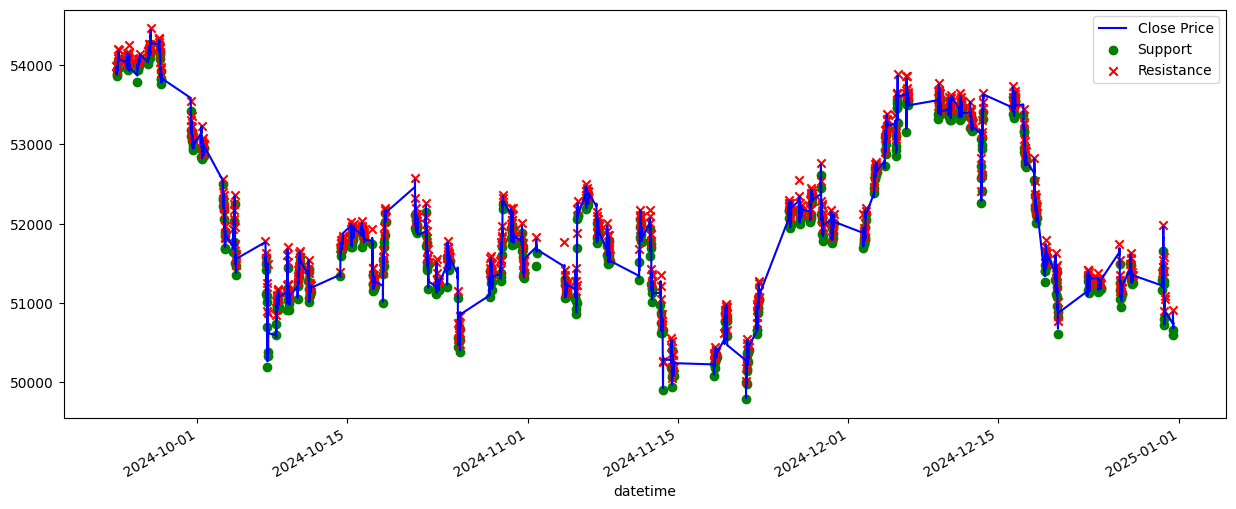

In [10]:
# Create a copy of the support and resistance columns to avoid modifying the original DataFrame
support_filtered = processed_df['support'].replace(0.0, float('nan'))
resistance_filtered = processed_df['resistance'].replace(0.0, float('nan'))

# Create a larger figure
plt.figure(figsize=(15, 6))

# Plot the close price
processed_df['close'].plot(label='Close Price', color='blue')

# Plot the support and resistance points, excluding 0/0.0 values
plt.scatter(processed_df.index, support_filtered, label='Support', color='green', marker='o')
plt.scatter(processed_df.index, resistance_filtered, label='Resistance', color='red', marker='x')

# Add legend and show plot
plt.legend()
plt.show()

In [11]:
class TradingEnvironment(gym.Env):
    def __init__(self, processed_df, initial_capital=10000, lot_size=quantity, brokerage=20,
                 max_trades_window=50, max_trades=10):
        """
        Initialize the Trading Environment.

        :param processed_df: DataFrame containing processed trading data with features.
        :param initial_capital: Starting capital for trading.
        :param lot_size: Number of lots to trade per action.
        :param brokerage: Fixed brokerage cost per transaction.
        :param max_trades_window: Time window to monitor overtrading.
        :param max_trades: Maximum allowed trades within the time window.
        """
        super(TradingEnvironment, self).__init__()

        # Store datetime index separately and reset it
        self.dates = processed_df.index
        self.data = processed_df.reset_index(drop=True)

        # Parameters
        self.initial_capital = initial_capital
        self.lot_size = lot_size  # Number of lots to trade
        self.brokerage = brokerage  # Brokerage charge per transaction (₹20)
        self.max_trades_window = max_trades_window
        self.max_trades = max_trades

        # Action space: 0 - Hold, 1 - Buy, 2 - Sell
        self.action_space = spaces.Discrete(3)

        # Observation space
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(self.data.shape[1],), dtype=np.float32
        )

        # Internal state
        self.reset()

    def reset(self, seed=None, options=None):
        """
        Reset the environment to initial state.

        :return: Initial observation and info.
        """
        super().reset(seed=seed)
        self.current_step = 0
        self.capital = self.initial_capital
        self.position = 0  # Positive for long, negative for short
        self.entry_price = 0
        self.total_trades = 0
        self.profitable_trades = 0
        self.trade_history = []  # To track trades for overtrading
        self.overtrading_count = 0
        return self.data.iloc[self.current_step].values, {}

    def step(self, action):
        """
        Execute one time step within the environment.

        :param action: Action to take (0: Hold, 1: Buy, 2: Sell)
        :return: Tuple of (observation, reward, done, info)
        """
        reward = 0
        done = False
        info = {}

        current_row = self.data.iloc[self.current_step]
        current_price = current_row["close"]
        stop_loss = current_row["Stop Loss"]
        target = current_row["Target"]

        # Extract additional features
        features = {
            "market_regime": current_row["market_regime"],
            "rsi": current_row["rsi"],
            "adx": current_row["adx"],
            "compression_ratio": current_row["compression_ratio"],
            "rsi": current_row["rsi"],
            "atr": current_row["atr"],
            "price_spread": current_row["price_spread"],
            "candle_to_atr": current_row["candle_to_atr"],
            "roc": current_row["roc"],
            "hv": current_row["hv"],
            "ema": current_row["ema"],
            "support": current_row["support"],
            "resistance": current_row["resistance"],
            "rsi_oscillation": current_row["rsi_oscillation"],
        }

        # Determine market context
        market_context = self._get_market_context(features)

        # Check if position needs to be closed
        if self.position != 0:
            trade_outcome, penalty = self._check_trade_outcome(current_price, stop_loss, target)
            if trade_outcome is not None:
                # Update trade history for overtrading
                self.trade_history.append(self.current_step)
                # Remove trades outside the window
                self._clean_trade_history()

                # Determine behavior flags
                behavior_flags = self._get_behavior_flags()

                # Calculate reward
                reward = self._calculate_reward(trade_outcome, market_context, behavior_flags, features)

                # Update trade counts
                self.total_trades += 1
                if trade_outcome["profit"] > 0:
                    self.profitable_trades += 1

        # Execute new action if no open position
        if action == 1 and self.position == 0:  # Buy
            self._open_position(current_price, direction=1)
            self.trade_history.append(self.current_step)
            self._clean_trade_history()
        elif action == 2 and self.position == 0:  # Sell
            self._open_position(current_price, direction=-1)
            self.trade_history.append(self.current_step)
            self._clean_trade_history()

        # Update overtrading count
        self.overtrading_count = len(self.trade_history)

        # Increment step
        self.current_step += 1
        if self.current_step >= len(self.data) - 1:
            done = True

        # Calculate portfolio value
        portfolio_value = self.capital + self._calculate_unrealized_pnl(current_price)

        # Prepare observation
        if not done:
            obs = self.data.iloc[self.current_step].values
        else:
            obs = np.zeros(self.data.shape[1])  # No observation if done

        # Prepare info
        info = {
            "capital": self.capital,
            "portfolio_value": portfolio_value,
            "win_rate": (self.profitable_trades / self.total_trades * 100) if self.total_trades > 0 else 0,
            "total_trades": self.total_trades,
            "profitable_trades": self.profitable_trades,
            "datetime": self.dates[self.current_step] if not done else self.dates[-1],
            "overtrading_count": self.overtrading_count,
        }

        return obs, reward, done, False, info

    def _open_position(self, price, direction):
        """
        Open a position with specified direction.

        :param price: Current price to enter the position.
        :param direction: 1 for long, -1 for short.
        """
        self.entry_price = price
        self.position = self.lot_size * direction
        self.capital -= self.brokerage  # Deduct brokerage on entry

    def _check_trade_outcome(self, price, stop_loss, target):
        """
        Check if the current position should be closed based on stop-loss or target.

        :param price: Current price.
        :param stop_loss: Stop-loss value.
        :param target: Target profit value.
        :return: Tuple of (trade_outcome_dict, penalty_flag) or (None, None)
        """
        if self.position > 0:  # Long position
            if price <= self.entry_price - stop_loss:  # Stop-loss hit
                pnl = -stop_loss * self.lot_size
                self.capital += pnl - self.brokerage
                trade_outcome = {
                    "profit": pnl,
                    "stop_loss_hit": True,
                    "trend_aligned": self._is_trend_aligned(1),
                    "position_held": False,
                }
                self.position = 0
                self.entry_price = 0
                penalty = True
                return trade_outcome, penalty
            elif price >= self.entry_price + target:  # Target hit
                pnl = target * self.lot_size
                self.capital += pnl - self.brokerage
                trade_outcome = {
                    "profit": pnl,
                    "stop_loss_hit": False,
                    "trend_aligned": self._is_trend_aligned(1),
                    "position_held": False,
                }
                self.position = 0
                self.entry_price = 0
                penalty = False
                return trade_outcome, penalty

        elif self.position < 0:  # Short position
            if price >= self.entry_price + stop_loss:  # Stop-loss hit
                pnl = -stop_loss * self.lot_size
                self.capital += pnl - self.brokerage
                trade_outcome = {
                    "profit": pnl,
                    "stop_loss_hit": True,
                    "trend_aligned": self._is_trend_aligned(-1),
                    "position_held": False,
                }
                self.position = 0
                self.entry_price = 0
                penalty = True
                return trade_outcome, penalty
            elif price <= self.entry_price - target:  # Target hit
                pnl = target * self.lot_size
                self.capital += pnl - self.brokerage
                trade_outcome = {
                    "profit": pnl,
                    "stop_loss_hit": False,
                    "trend_aligned": self._is_trend_aligned(-1),
                    "position_held": False,
                }
                self.position = 0
                self.entry_price = 0
                penalty = False
                return trade_outcome, penalty

        return None, None

    def _is_trend_aligned(self, direction):
        """
        Check if the trade direction is aligned with the market trend.

        :param direction: 1 for long, -1 for short.
        :return: Boolean indicating alignment.
        """
        return (self.data.iloc[self.current_step]["market_regime"] == 1 and direction == 1) or \
               (self.data.iloc[self.current_step]["market_regime"] == -1 and direction == -1)

    def _clean_trade_history(self):
        """
        Remove trades that are outside the monitoring window to track overtrading.
        """
        window_start = max(0, self.current_step - self.max_trades_window)
        self.trade_history = [trade for trade in self.trade_history if trade >= window_start]

    def _get_behavior_flags(self):
        """
        Determine behavioral flags based on trade history and current state.

        :return: Dictionary of behavior flags.
        """
        behavior_flags = {
            "overtrading": len(self.trade_history) > self.max_trades,
            "ignored_stop_loss": False,  # Placeholder for future implementation
            "exit_after_profit": True,  # Assumed true as positions are closed immediately
            "low_frequency_sideways": not self._is_trading_in_sideways(),
        }
        return behavior_flags

    def _is_trading_in_sideways(self):
        """
        Check if the current trade is in a sideways market.

        :return: Boolean indicating if trading in sideways market.
        """
        return self.data.iloc[self.current_step]["market_regime"] == 0

    def _get_market_context(self, features):
        """
        Determine the current market context based on features.

        :param features: Dictionary of current features.
        :return: Dictionary of market context.
        """
        market_context = {
            "is_trending": features["market_regime"] == 1,
            "is_sideways": features["market_regime"] == 0,
            "is_volatile": features["atr"] > self._get_atr_threshold(),
            "volatility": "high" if features["atr"] > self._get_atr_threshold() else "low",
            "atr_threshold": self._get_atr_threshold(),
        }
        return market_context

    def _get_atr_threshold(self):
        """
        Calculate ATR threshold for determining market volatility.

        :return: ATR threshold value.
        """
        # Example: Median ATR over the window or a fixed value
        return self.data["atr"].median()

    def _calculate_reward(self, trade_outcome, market_context, behavior_flags, features):
        """
        Calculate the reward based on trade outcome, market conditions, and behavior.

        :param trade_outcome: Dictionary containing trade outcome details.
        :param market_context: Dictionary containing current market context.
        :param behavior_flags: Dictionary containing behavior flags.
        :param features: Dictionary of current features.
        :return: Reward value on a 0–100 scale.
        """
        # Base Reward (0–50)
        if trade_outcome["profit"] > 0:
            base_reward = 50
        elif trade_outcome["stop_loss_hit"]:
            base_reward = 0
        else:
            base_reward = 0  # Can adjust if needed

        # Market Conditions Rewards (0–30)
        market_reward = 0
        if market_context["is_trending"]:
            if trade_outcome["trend_aligned"]:
                market_reward += 20  # Aligned with trend
            else:
                market_reward -= 10  # Against trend
        elif market_context["is_sideways"]:
            if not trade_outcome["position_held"]:
                market_reward += 5  # Staying out
            else:
                market_reward -= 10  # Took trade in sideways
        elif market_context["is_volatile"]:
            if trade_outcome["profit"] > 0:
                market_reward += 10  # Profitable in volatile
            else:
                market_reward -= 10  # Unprofitable in volatile

        # Feature-based Adjustments
        # RSI
        if features["rsi"] < 30 or features["rsi"] > 70:
            if trade_outcome["profit"] > 0:
                market_reward += 5  # Reward for trading at extreme RSI
            else:
                market_reward -= 5  # Penalize for trading against RSI

        # ADX
        if features["adx"] > 25:
            if trade_outcome["profit"] > 0:
                market_reward += 10  # Strong trend support
            else:
                market_reward -= 10  # Strong trend against

        # Compression Ratio
        if features["compression_ratio"] > 0.1:
            if trade_outcome["profit"] > 0:
                market_reward += 5  # Breakout potential rewarded
            else:
                market_reward -= 5  # Breakout failure penalized

        # Candle-to-ATR
        if features["candle_to_atr"] > 1.5:
            if trade_outcome["profit"] > 0:
                market_reward += 5  # Strong candle movement rewarded
            else:
                market_reward -= 5  # Strong candle movement against penalized

        # Behavioral Adjustments (-20 to +20)
        behavior_reward = 0
        if behavior_flags["overtrading"]:
            behavior_reward -= 15  # Heavy penalty for overtrading
        if behavior_flags["ignored_stop_loss"]:
            behavior_reward -= 10  # Penalty for ignoring stop-loss
        if behavior_flags["exit_after_profit"]:
            behavior_reward += 10  # Reward for exiting after profit
        if behavior_flags["low_frequency_sideways"]:
            behavior_reward += 5  # Reward for avoiding sideways markets

        # Total Reward Calculation
        total_reward = base_reward + market_reward + behavior_reward
        total_reward = max(0, min(100, total_reward))  # Ensure reward stays within 0–100

        return total_reward

    def _calculate_unrealized_pnl(self, current_price):
        """
        Calculate unrealized PnL for the current position.

        :param current_price: Current market price.
        :return: Unrealized PnL value.
        """
        if self.position > 0:
            return (current_price - self.entry_price) * self.position
        elif self.position < 0:
            return (self.entry_price - current_price) * abs(self.position)
        return 0

    def render(self, mode='human'):
        """
        Render the environment (optional).

        :param mode: Mode to render with.
        """
        profit = self.capital - self.initial_capital
        print(f'Step: {self.current_step}')
        print(f'Capital: {self.capital}')
        print(f'Position: {"Long" if self.position > 0 else "Short" if self.position < 0 else "None"}')
        print(f'Profit: {profit}')

    def close(self):
        """
        Close the environment (optional).
        """
        pass

In [12]:
class ReplayBuffer:
    def __init__(self, file_path="replay_buffer.pkl"):
        self.buffer = []
        self.file_path = file_path
        self._load()

    def add(self, observation, action, reward, next_observation, done):
        self.buffer.append((observation, action, reward, next_observation, done))

    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)

    def save(self):
        with open(self.file_path, "wb") as f:
            pickle.dump(self.buffer, f)

    def _load(self):
        try:
            with open(self.file_path, "rb") as f:
                self.buffer = pickle.load(f)
        except FileNotFoundError:
            self.buffer = []

In [13]:
# Policy Network
def create_policy_network(input_shape, action_space):
    model = tf.keras.Sequential([
        layers.InputLayer(shape=input_shape),
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(action_space, activation='softmax')  # Output probabilities for actions
    ])
    return model

# MAML Agent
class MAMLAgent:
    def __init__(self, env, learning_rate=0.01, meta_lr=0.001):
        self.env = env
        self.policy = create_policy_network(
            input_shape=env.observation_space.shape,
            action_space=env.action_space.n
        )
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=meta_lr)
        self.inner_lr = learning_rate
        self.meta_batch_size = 4  # Number of tasks to sample per meta-update
        self.replay_buffer = ReplayBuffer()
        self.trade_log = []  # Track trade entries

    def inner_update(self, task_data):
        with tf.GradientTape() as tape:
            observations, actions, rewards = task_data
            logits = self.policy(observations)
            loss = self._compute_loss(logits, actions, rewards)
        grads = tape.gradient(loss, self.policy.trainable_variables)
        return grads

    def meta_update(self, meta_gradients):
        self.optimizer.apply_gradients(zip(meta_gradients, self.policy.trainable_variables))

    def _compute_loss(self, logits, actions, rewards):
        action_probs = tf.reduce_sum(actions * tf.nn.softmax(logits), axis=1)
        loss = -tf.reduce_mean(tf.math.log(action_probs) * rewards)
        return loss

    def train(self, num_iterations=100):
        capital_history = []
        for iteration in range(num_iterations):
            meta_gradients = [tf.zeros_like(var) for var in self.policy.trainable_variables]
            for _ in range(self.meta_batch_size):
                task_data = self._sample_task()
                grads = self.inner_update(task_data)
                meta_gradients = [
                    mg + g for mg, g in zip(meta_gradients, grads)
                ]
            self.meta_update(meta_gradients)

            # Collect metrics
            capital_history.append(self.env.capital)
            print(f"Iteration {iteration + 1}/{num_iterations} complete.")
            print(f"Capital: {self.env.capital}, Win Rate: {(self.env.profitable_trades / max(1, self.env.total_trades) * 100):.2f}")

        return capital_history

    def _sample_task(self):
        obs, rewards, actions, next_obs, dones = [], [], [], [], []
        self.env.reset()
        done = False
        while not done:
            current_obs = self.env.data.iloc[self.env.current_step].values
            action = np.random.choice(self.env.action_space.n)
            obs.append(current_obs)
            actions.append(action)
            next_observation, reward, done, _, _ = self.env.step(action)
            rewards.append(reward)
            next_obs.append(next_observation)
            dones.append(done)

            # Save to replay buffer
            self.replay_buffer.add(current_obs, action, reward, next_observation, done)

            # Log trades
            if action == 1:  # Buy
                self.trade_log.append({"step": self.env.current_step, "action": "buy", "price": self.env.data.iloc[self.env.current_step]["close"]})
            elif action == 2:  # Sell
                self.trade_log.append({"step": self.env.current_step, "action": "sell", "price": self.env.data.iloc[self.env.current_step]["close"]})

        return (
            tf.convert_to_tensor(np.array(obs), dtype=tf.float32),
            tf.convert_to_tensor(np.eye(self.env.action_space.n)[actions], dtype=tf.float32),
            tf.convert_to_tensor(np.array(rewards), dtype=tf.float32),
        )

In [14]:
def visualize_performance(capital_history, trade_log, df):
    # Plot capital over time
    plt.figure(figsize=(12, 6))
    plt.plot(capital_history, label='Capital', color='blue')
    plt.title('Capital Over Time')
    plt.xlabel('Iteration')
    plt.ylabel('Capital')
    plt.legend()
    plt.show()

    # Scatter buy/sell entries on closing price
    plt.figure(figsize=(12, 6))
    plt.plot(df['close'], label='Close Price', color='black', alpha=0.5)
    buys = [log['step'] for log in trade_log if log['action'] == 'buy']
    sells = [log['step'] for log in trade_log if log['action'] == 'sell']
    plt.scatter(buys, df['close'].iloc[buys], label='Buy', color='green', marker='^', alpha=0.7)
    plt.scatter(sells, df['close'].iloc[sells], label='Sell', color='red', marker='v', alpha=0.7)
    plt.title('Trade Entries on Closing Price')
    plt.xlabel('Time Step')
    plt.ylabel('Price')
    plt.legend()
    plt.show()

In [ ]:
# Initialize environment and agent
env = TradingEnvironment(processed_df)
agent = MAMLAgent(env)

# Train agent
capital_history = agent.train(num_iterations=5)

# Save replay buffer
agent.replay_buffer.save()

# Visualize performance
visualize_performance(capital_history, agent.trade_log, processed_df)

Iteration 1/5 complete.
Capital: 48528.981591365016, Win Rate: 35.71
Iteration 2/5 complete.
Capital: 15695.157431310714, Win Rate: 34.94


In [ ]:
class LiveTradingAgent:
    def __init__(self, maml_agent, live_env, replay_buffer):
        """
        Initialize the live trading agent with a trained MAML agent and a replay buffer.
        :param maml_agent: Trained MAML agent.
        :param live_env: Live trading environment.
        :param replay_buffer: Replay buffer for storing and reusing experiences.
        """
        self.agent = maml_agent
        self.env = live_env
        self.replay_buffer = replay_buffer

    def predict_action(self, observation):
        """
        Predict action for the latest data point.
        :param observation: The most recent data point (features).
        :return: Action (0: Hold, 1: Buy, 2: Sell).
        """
        observation = tf.convert_to_tensor(observation, dtype=tf.float32)
        observation = tf.expand_dims(observation, axis=0)  # Add batch dimension
        logits = self.agent.policy(observation)
        action = tf.argmax(logits, axis=1).numpy()[0]  # Choose the action with the highest probability
        return action

    def update_model(self, batch_size=32):
        """
        Perform gradient updates using a sampled batch from the replay buffer.
        :param batch_size: Number of samples to use for the update.
        """
        if len(self.replay_buffer.buffer) < batch_size:
            return  # Skip if not enough samples in the buffer

        # Sample a batch from the replay buffer
        batch = self.replay_buffer.sample(batch_size)
        observations, actions, rewards = [], [], []

        for obs, action, reward, _, _ in batch:
            observations.append(obs)
            actions.append(action)
            rewards.append(reward)

        observations = tf.convert_to_tensor(observations, dtype=tf.float32)
        actions_one_hot = tf.one_hot(actions, depth=self.env.action_space.n, dtype=tf.float32)
        rewards = tf.convert_to_tensor(rewards, dtype=tf.float32)

        with tf.GradientTape() as tape:
            logits = self.agent.policy(observations)
            loss = self.agent._compute_loss(logits, actions_one_hot, rewards)

        gradients = tape.gradient(loss, self.agent.policy.trainable_variables)
        self.agent.optimizer.apply_gradients(zip(gradients, self.agent.policy.trainable_variables))

    def run_live_trading(self, live_df):
        """
        Process the live data DataFrame for continuous predictions and updates.
        :param live_df: DataFrame containing live data (new rows added in real-time).
        """
        for index, row in live_df.iterrows():
            observation = row.values  # Features for the latest data point

            # Predict action
            action = self.predict_action(observation)

            # Print action
            action_str = "Buy" if action == 1 else "Sell" if action == 2 else "Hold"
            print(f"Action: {action_str}")

            # If action is Buy or Sell, ask for feedback
            reward = 0
            if action in [1, 2]:
                feedback = input(f"Enter feedback for {action_str} (profit/loss as numeric value): ")
                try:
                    reward = float(feedback)
                except ValueError:
                    print("Invalid feedback. Skipping update.")
                    continue

            # Store experience in replay buffer
            self.replay_buffer.add(observation, action, reward, None, False)

            # Save replay buffer to file after every experience
            self.replay_buffer.save()

            # Update the model using replay buffer
            self.update_model()

In [ ]:
def get_sleep_time(interval_minutes, market_start_hour=9, market_start_minute=15):
    now = datetime.now()
    market_start_time = now.replace(hour=market_start_hour, minute=market_start_minute, second=0, microsecond=0)

    if now < market_start_time:
        # If current time is before the market starts, set next_run_time to market start time
        next_run_time = market_start_time
    else:
        # Calculate the minutes since the market start time
        minutes_since_market_start = (now - market_start_time).total_seconds() // 60
        # Calculate the number of minutes to the next interval boundary
        minutes_to_next_interval = interval_minutes - (minutes_since_market_start % interval_minutes)
        # Calculate the next run time by adding these minutes to the current time
        next_run_time = (now + timedelta(minutes=minutes_to_next_interval)).replace(second=0, microsecond=0)

    # Calculate the sleep time in seconds
    sleep_time = (next_run_time - now).total_seconds()
    return sleep_time

In [ ]:
while True:
    # Fetch and process live data
    live_df = fetch_candle_data(100)  # Fetch last 100 candles
    live_data_processor = DataProcessor(live_df, peak_length=14, indicator_length=14)
    live_processed_df = live_data_processor.process().train_df

    # Load replay buffer
    live_replay_buffer = ReplayBuffer("replay_buffer.pkl")

    # Initialize environment and agent
    live_env = TradingEnvironment(live_processed_df)
    live_agent = LiveTradingAgent(agent, live_env, live_replay_buffer)

    # Get the latest data point
    latest_data = live_processed_df.iloc[-1]
    latest_features = latest_data.values

    # Predict action
    action = live_agent.predict_action(latest_features)
    action_str = "Buy" if action == 1 else "Sell" if action == 2 else "Hold"
    print(f"Predicted Action: {action_str}")

    # Skip further steps if action is Hold
    if action == 0:  # Hold
        sleep_time = get_sleep_time(interval_minutes)
        print(f"Sleeping for {sleep_time} seconds...")
        time.sleep(sleep_time)
        continue

    # Calculate Target and Stop-Loss
    close_price = latest_data["close"]
    target = latest_data["Target"]
    stop_loss = latest_data["Stop Loss"]
    target_price = close_price + target if action == 1 else close_price - target  # Target for Buy or Sell
    stop_loss_price = close_price - stop_loss if action == 1 else close_price + stop_loss  # SL for Buy or Sell

    # Monitor subsequent candles to evaluate the trade
    trade_outcome = None
    while trade_outcome is None:
        # Fetch new data
        live_df = fetch_candle_data(100)
        live_data_processor = DataProcessor(live_df, peak_length=14, indicator_length=14)
        live_processed_df = live_data_processor.process().train_df
        new_data = live_processed_df.iloc[-1]

        # Check if target or stop-loss is hit
        if action == 1:  # Buy
            if new_data["close"] >= target_price:
                trade_outcome = 1  # Profit
                print("Target hit for Buy action. Trade closed with profit.")
            elif new_data["close"] <= stop_loss_price:
                trade_outcome = -1  # Loss
                print("Stop-Loss hit for Buy action. Trade closed with loss.")
        elif action == 2:  # Sell
            if new_data["close"] <= target_price:
                trade_outcome = 1  # Profit
                print("Target hit for Sell action. Trade closed with profit.")
            elif new_data["close"] >= stop_loss_price:
                trade_outcome = -1  # Loss
                print("Stop-Loss hit for Sell action. Trade closed with loss.")

        # Sleep before the next refresh
        sleep_time = get_sleep_time(interval_minutes)
        print(f"Sleeping for {sleep_time} seconds...")
        time.sleep(sleep_time)

    # Update the model based on the trade outcome
    reward = trade_outcome * abs(target_price - close_price)  # Reward is profit/loss magnitude
    live_agent.update_model(latest_features, action, reward)

    # Add experience to replay buffer
    live_replay_buffer.add(latest_features, action, reward, None, False)
    live_replay_buffer.save()